In [1]:
import pandas as pd

df = pd.read_excel("data/HousePricePrediction.xlsx")
df.head()


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [2]:
df = df.rename(columns={
    "MSSubClass": "House_Style",
    "MSZoning": "Area_Type",
    "LotArea": "Land_Size",
    "LotConfig": "Land_Position",
    "BldgType": "Building_Type",
    "OverallCond": "House_Condition",
    "YearBuilt": "Built_Year",
    "YearRemodAdd": "Renovation_Year",
    "Exterior1st": "Outer_Material",
    "BsmtFinSF2": "Finished_Basement",
    "TotalBsmtSF": "Basement_Size",
    "SalePrice": "Price"
})
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 2919 non-null   int64  
 1   House_Style        2919 non-null   int64  
 2   Area_Type          2915 non-null   object 
 3   Land_Size          2919 non-null   int64  
 4   Land_Position      2919 non-null   object 
 5   Building_Type      2919 non-null   object 
 6   House_Condition    2919 non-null   int64  
 7   Built_Year         2919 non-null   int64  
 8   Renovation_Year    2919 non-null   int64  
 9   Outer_Material     2918 non-null   object 
 10  Finished_Basement  2918 non-null   float64
 11  Basement_Size      2918 non-null   float64
 12  Price              1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [3]:
# Checking Correlation with price

df.corr(numeric_only=True)["Price"].sort_values(ascending=False)


Price                1.000000
Basement_Size        0.613581
Built_Year           0.522897
Renovation_Year      0.507101
Land_Size            0.263843
Finished_Basement   -0.011378
Id                  -0.021917
House_Condition     -0.077856
House_Style         -0.084284
Name: Price, dtype: float64

In [4]:
# Selecting Features

df = df.drop([
    "Id",
    "Finished_Basement",
    "House_Condition",
    "House_Style"
], axis=1)


selected_features = [
    "Basement_Size",
    "Built_Year",
    "Renovation_Year",
    "Land_Size"
]


X = df[selected_features]
y = df["Price"]

print(X.head())
print(y.head())


   Basement_Size  Built_Year  Renovation_Year  Land_Size
0          856.0        2003             2003       8450
1         1262.0        1976             1976       9600
2          920.0        2001             2002      11250
3          756.0        1915             1970       9550
4         1145.0        2000             2000      14260
0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: Price, dtype: float64


In [5]:
print(X.isnull().sum())
y.isnull().sum()  # df["Price"].isnull().sum()



Basement_Size      1
Built_Year         0
Renovation_Year    0
Land_Size          0
dtype: int64


np.int64(1459)

In [6]:
# Filling and Droping missing values


df_clean = df.dropna(subset=["Price"])

# updating X and y
X = df_clean[selected_features]
y = df_clean['Price']  

# X = X.fillna(X.mean()) --> it works when still features have missing values.

print(X.info())
print(y.info())
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Basement_Size    1460 non-null   float64
 1   Built_Year       1460 non-null   int64  
 2   Renovation_Year  1460 non-null   int64  
 3   Land_Size        1460 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 57.0 KB
None
<class 'pandas.core.series.Series'>
Index: 1460 entries, 0 to 1459
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
1460 non-null   float64
dtypes: float64(1)
memory usage: 22.8 KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area_Type        1460 non-null   object 
 1   Land_Size        1460 non-null   int64  
 2   Land_Position    1460 non-null   object 
 3   Building_Type    1460 non-n

In [7]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)




# ================= TRAIN-TEST SPLIT =================
# Splits dataset into training and testing sets.
# Model learns from training data and is evaluated on test data.

# 1. Pehle X split hoga → train & test
# 2. Phir y split hoga → train & test

# test_size=0.2
# → 20% data for testing
# → 80% data for training

# random_state=42
# → Fixes random splitting for reproducibility.
# → Same train/test split every time code runs.
# → Ensures consistent results and fair model comparison.

# Without random_state:
# → Data split changes every run.
# → Model scores may slightly vary each time.

# Output:
# Returned order is IMPORTANT and always:
# X_train, X_test, y_train, y_test

# Meaning:
# X_train ↔ y_train  (used for training the model)
# X_test  ↔ y_test   (used for evaluating the model)

# The split keeps row alignment.
# Each row in X_train corresponds to the same row in y_train.
# Each row in X_test corresponds to the same row in y_test.

# X_train, y_train → used to train model
# X_test, y_test   → used to evaluate model
# =====================================================


(1168, 4)
(292, 4)


In [8]:
# creates a Linear Regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)




# ================= LINEAR REGRESSION WORKFLOW =================

# 1️⃣ Create Model
# LinearRegression() creates an empty model object.
# At this stage, model has NOT learned anything.

# 2️⃣ Train Model (fit)
# model.fit(X_train, y_train)
# → Learns relationship between features (X) and target (y).
# → Internally calculates weights (coefficients) and intercept.
# → After this step, model is considered "trained".

# 3️⃣ Make Predictions (predict)
# y_pred = model.predict(X_test)
# → Uses learned weights from training.
# → Applies formula: y = w1*x1 + w2*x2 + ... + b
# → Generates predicted values for unseen test data.

# ⚠ Important:
# If fit() is not called before predict(),
# model will raise NotFittedError.
# ===============================================================

In [9]:
# Evaluate

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



# ================= MODEL EVALUATION =================

# Importing Evaluation metrics for testing model performance.

# R² Score:
# Measures how well the model explains variance in target.
# Range:
# 1.0  → Perfect prediction
# 0.0  → No better than mean prediction
# < 0  → Very poor model

# RMSE (Root Mean Squared Error):
# Measures average prediction error.
# Same unit as target variable (e.g., price).
# Lower RMSE → Better model performance.

# Example:

# RMSE = 100000
# → On average prediction ₹1 lakh se galat ho sakta hai.

# R² focuses on goodness of fit.
# RMSE focuses on magnitude of error.

# ====================================================

# ================= METRIC INTERPRETATION GUIDE =================

# R² (Coefficient of Determination):
# → Measures how much variance in target is explained by model.
# → Range:
#    1.0  → Perfect prediction
#    0.0  → Same as predicting mean
#   < 0   → Worse than mean prediction

# RMSE (Root Mean Squared Error):
# → Measures average prediction error (in actual unit, e.g., price).
# → Lower RMSE = better.
# → Same unit as target variable.

# ---------------- Interpretation Cases ----------------

# 1️⃣ High R² + Low RMSE
# → Ideal case.
# → Model explains pattern well and makes small errors.

# 2️⃣ High R² + High RMSE
# → Data scale may be large.
# → Model captures pattern, but absolute errors look big due to large target values.

# 3️⃣ Low R² + Small RMSE
# → Model likely predicting near mean.              
# → Not learning real pattern.
# → Data variation may be small.
# Example:
# House prices range:
# ₹ 10,00,000 to ₹ 10,50,000
# Very small variation.
# Agar model sabko approx ₹10,25,000 predict kare:
#  - Error small hoga → RMSE small
#  - But variation explain nahi kiya → R² low

# 4️⃣ Low R² + High RMSE
# → Poor model.
# → Large errors and weak pattern learning.

# 5️⃣ R² = 1 and RMSE = 0
# → Perfect prediction (rare in real-world data).
# → Usually indicates overfitting or synthetic data.

# Situation	            Meaning
# High R² + Low RMSE  =	Ideal model
# High R² + High RMSE	=   Data scale large
# Low R² + Small RMSE	=   Model predicting near mean
# Low R² + High RMSE	=   Bad model
# ======================================================

R2 Score: 0.5690241206312561
RMSE: 57495.43966426897


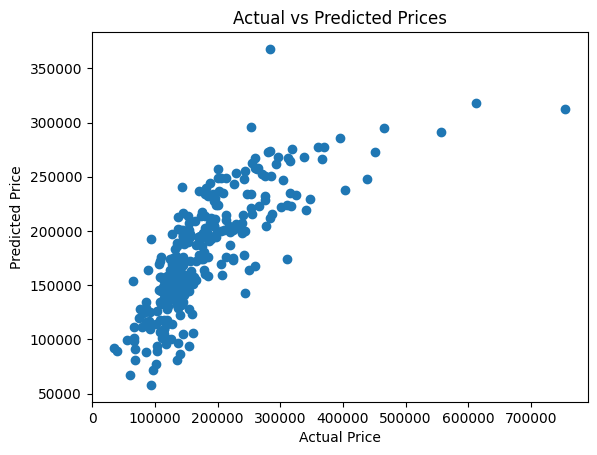

In [10]:
# Plot Actual vs Predicted

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


In [11]:
# Check Model Equation

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Feature Names:", X.columns)


Intercept: -2913625.231264993
Coefficients: [  70.44328909  491.82804982 1027.32083751    1.10102327]
Feature Names: Index(['Basement_Size', 'Built_Year', 'Renovation_Year', 'Land_Size'], dtype='object')


In [12]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, y_pred_rf))


Random Forest R2: 0.7569480706901529


In [13]:
# Train final model on FULL dataset


rf_final = RandomForestRegressor(random_state=42)
rf_final.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
# Saving in pikle

import joblib
joblib.dump(rf_final, "house_price_model.pkl")
joblib.dump(X.columns.tolist(), "feature_order.pkl")


['feature_order.pkl']

In [15]:
# What I Just Did:

# 1. Selected strong features

# 2. Cleaned missing values

# 3. Trained Linear Regression

# 4. Compared with Random Forest

# 5. Observed improvement from 0.56 → 0.75